<a href="https://colab.research.google.com/github/AlibekZolotov/cifar10-cnn-optimizer-comparison/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

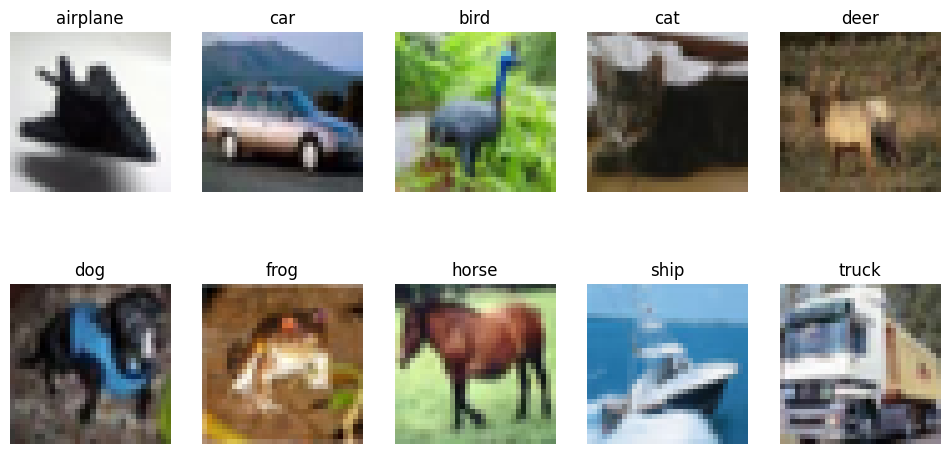

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 933,898 (3.56 MB)

 Trainable params: 933,898 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.1845 - loss: 2.1991 - val_accuracy: 0.3092 - val_loss: 1.9649
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3702 - loss: 1.7605 - val_accuracy: 0.4245 - val_loss: 1.5860
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4416 - loss: 1.5542 - val_accuracy: 0.4715 - val_loss: 1.4710
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4849 - loss: 1.4368 - val_accuracy: 0.4101 - val_loss: 1.6658
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5208 - loss: 1.3464 - val_accuracy: 0.5106 - val_loss: 1.3547
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5517 - loss: 1.2573 - val_accuracy: 0.5135 - val_loss: 1.3562
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5820 - loss: 1.1712 - val_accuracy: 0.5641 - val_loss: 1.2026
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6052 - loss: 1.1087 - val_acc

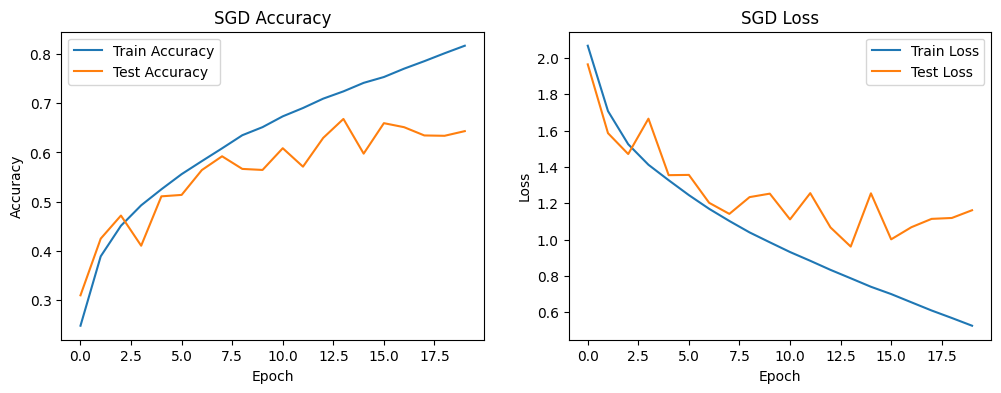

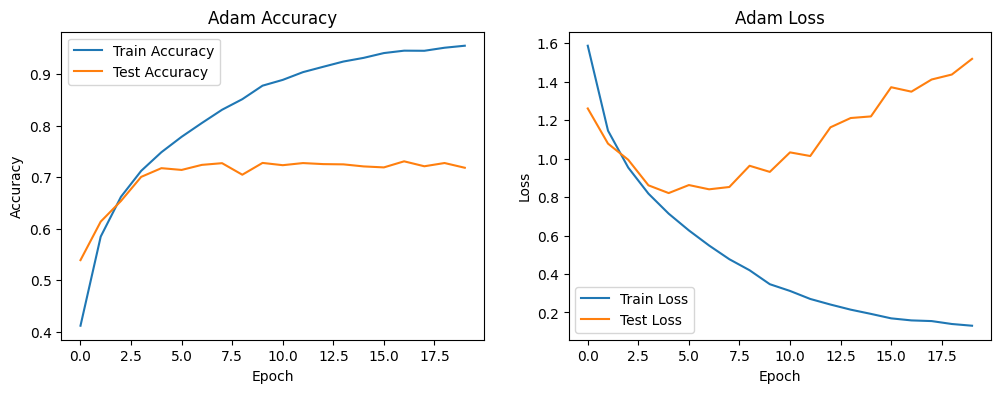

  Optimizer  Test Accuracy  Test Loss
0       SGD         0.6433   1.161627
1      Adam         0.7183   1.519006


In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(12,6))
for i in range(10):
    index = np.argmax(y_train[:,i])
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index])
    plt.title(class_names[i])
    plt.axis('off')
plt.show()

def create_cnn_model():
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
        MaxPooling2D((2,2)),
        Conv2D(64,(3,3),activation='relu',padding='same'),
        Conv2D(64,(5,5),activation='relu',padding='same'),
        Conv2D(128,(5,5),activation='relu',padding='same'),
        Conv2D(64,(3,3),activation='relu',padding='same'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128,activation='relu'),
        Dense(64,activation='relu'),
        Dense(10,activation='softmax')
    ])
    return model

model_sgd = create_cnn_model()
model_sgd.summary()
model_sgd.compile(optimizer=SGD(), loss='categorical_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))

model_adam = create_cnn_model()
model_adam.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))

sgd_test_loss, sgd_test_acc = model_sgd.evaluate(x_test, y_test, verbose=0)
adam_test_loss, adam_test_acc = model_adam.evaluate(x_test, y_test, verbose=0)
print("SGD - Test Accuracy:", sgd_test_acc, "Test Loss:", sgd_test_loss)
print("Adam - Test Accuracy:", adam_test_acc, "Test Loss:", adam_test_loss)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_sgd.history['accuracy'], label='Train Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Test Accuracy')
plt.title("SGD Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_sgd.history['loss'], label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Test Loss')
plt.title("SGD Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_adam.history['accuracy'], label='Train Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Test Accuracy')
plt.title("Adam Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_adam.history['loss'], label='Train Loss')
plt.plot(history_adam.history['val_loss'], label='Test Loss')
plt.title("Adam Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

